# MixUp Regressor-Modelle auf dem Lebenshilfe-Datensatz evaluieren

Dieses Notebook evaluiert die vier trainierten MixUp-Regressoren auf dem ungesehenen Lebenshilfe-Testset:
1. **Variante A (Statisch):** Modell mit festem Mischen/Shuffling in `__init__`.
2. **Variante B (Dynamisch):** Modell mit rein dynamischem Mischen/Shuffling in `__getitem__`.
3. **Variante C (Hybrid):** Modell mit linear ansteigender Dynamic-Wahrscheinlichkeit ($p_{dynamic}$).
4. **Variante D (Hybrid + Cyclic LR):** Modell mit Hybrid-Mischen und Cosinus-Lernratenscheduling.

Da die Regressoren trainiert wurden, um den Anteil einfacher Sprache ($\lambda$) in gemischten Absätzen vorherzusagen, erwarten wir für reine Texte der Einfachen Sprache (LS) $\lambda \approx 1.0$ und für Alltagssprache (AS) $\lambda \approx 0.0$.

In [9]:
import os
import json
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import accuracy_score, balanced_accuracy_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Device: {DEVICE}")

Nutze Device: cpu


In [10]:
# 1. Daten laden und Vokabular rekonstruieren (exakt identisch zum Training)
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= 0.8) & (df["semantic_similarity_8192"] <= 0.98)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df_filtered, test_size=0.1, random_state=42)

class Vocab:
    def __init__(self, token_list, max_size=20000, min_freq=2):
        counter = Counter(token_list)
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
                
    def __len__(self):
        return len(self.itos)
    
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

print("Sammle Tokens für das Vokabular...")
all_train_tokens = []
nlp_vocab = spacy.load('de_core_news_sm', disable=['ner', 'tagger', 'lemmatizer'])
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Vokab-Tokens sammeln"):
    for text in [str(row["ls_text"]), str(row["as_text"])]:
        doc = nlp_vocab(text)
        for token in doc:
            if not token.is_space:
                all_train_tokens.append(token.text.lower())

vocab = Vocab(all_train_tokens, max_size=25000, min_freq=2)
print(f"Vokabular-Größe: {len(vocab)}")

Sammle Tokens für das Vokabular...


Vokab-Tokens sammeln: 100%|██████████| 928/928 [00:17<00:00, 51.67it/s]

Vokabular-Größe: 11006


In [11]:
# 2. Modellarchitektur definieren (BiLSTM Regressor)
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

In [12]:
# 3. Funktion zum Laden der Modelle definieren
def load_model(path, vocab_size):
    model = BiLSTMRegressor(vocab_size, embed_dim=128, hidden_dim=128)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        print(f"Modell erfolgreich geladen: {path}")
        return model
    else:
        print(f"Fehler: Modelldatei nicht gefunden bei {path}")
        return None

models = {
    "Variante A (Statisch)": load_model("../results/bilstm_mixup_regression_static.pt", len(vocab)),
    "Variante B (Dynamisch)": load_model("../results/bilstm_mixup_regression_getitem.pt", len(vocab)),
    "Variante C (Hybrid)": load_model("../results/bilstm_mixup_regression_hybrid.pt", len(vocab)),
    "Variante D (Hybrid + Cyclic)": load_model("../results/bilstm_mixup_regression_hybrid_cyclic.pt", len(vocab))
}

Modell erfolgreich geladen: ../results/bilstm_mixup_regression_static.pt
Modell erfolgreich geladen: ../results/bilstm_mixup_regression_getitem.pt
Modell erfolgreich geladen: ../results/bilstm_mixup_regression_hybrid.pt
Modell erfolgreich geladen: ../results/bilstm_mixup_regression_hybrid_cyclic.pt


In [13]:
# 4. Lebenshilfe-Datensatz laden und spacy-basierte Bündelung vorbereiten
nlp = spacy.load('de_core_news_sm', disable=['ner', 'tagger', 'lemmatizer'])
LH_DATASET_PATH = "../results/lebenshilfe_dataset_no_paragraphs.json"

with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)
print(f"Anzahl geladener Lebenshilfe Artikelpaare: {len(lh_data)}")

def text_to_sequences(text, vocab, max_seq_len=150):
    doc = nlp(text)
    sequences = []
    current_seq = []
    for sent in doc.sents:
        tokens = [t.text.lower() for t in sent if not t.is_space]
        if len(tokens) == 0:
            continue
        if len(current_seq) + len(tokens) > max_seq_len:
            if len(current_seq) > 0:
                sequences.append(current_seq)
            current_seq = tokens[:max_seq_len]
        else:
            current_seq.extend(tokens)
    if len(current_seq) > 0:
        sequences.append(current_seq)
        
    padded_sequences = []
    for seq in sequences:
        encoded = vocab.encode(seq)
        if len(encoded) > max_seq_len:
            encoded = encoded[:max_seq_len]
        else:
            encoded = encoded + [0] * (max_seq_len - len(encoded))
        padded_sequences.append(encoded)
    return padded_sequences

Anzahl geladener Lebenshilfe Artikelpaare: 49


In [14]:
# 5. Vorhersagen für alle Modelle generieren
results = {}
for model_name, model in models.items():
    if model is None:
        continue
    results[model_name] = {"ls_preds": [], "as_preds": []}
    
    for item in tqdm(lh_data, desc=f"Vorhersagen für {model_name}"):
        ls_text = item.get("ls_text", "")
        as_text = item.get("as_text", "")
        
        # LS (Einfache Sprache)
        ls_seqs = text_to_sequences(ls_text, vocab)
        if ls_seqs:
            tensors = torch.tensor(ls_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                results[model_name]["ls_preds"].extend(preds)
                
        # AS (Alltagssprache)
        as_seqs = text_to_sequences(as_text, vocab)
        if as_seqs:
            tensors = torch.tensor(as_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                results[model_name]["as_preds"].extend(preds)

Vorhersagen für Variante D (Hybrid + Cyclic): 100%|██████████| 49/49 [00:06<00:00,  7.73it/s]


In [15]:
# 6. Metriken berechnen und als Vergleichstabelle ausgeben
table_rows = []
for model_name in results.keys():
    ls_p = results[model_name]["ls_preds"]
    as_p = results[model_name]["as_preds"]
    
    mean_ls = np.mean(ls_p)
    mean_as = np.mean(as_p)
    
    # Binäre Klassifikation mit Schwellenwert 0.5
    correct_ls = sum(1 for p in ls_p if p > 0.5)
    correct_as = sum(1 for p in as_p if p <= 0.5)
    
    acc = (correct_ls + correct_as) / (len(ls_p) + len(as_p))
    
    bacc_ls = correct_ls / len(ls_p)
    bacc_as = correct_as / len(as_p)
    bacc = (bacc_ls + bacc_as) / 2
    
    # MAE (LS-Abweichung von 1.0, AS-Abweichung von 0.0)
    mae = (sum(1.0 - p for p in ls_p) + sum(p for p in as_p)) / (len(ls_p) + len(as_p))
    
    table_rows.append({
        "Modell": model_name,
        "Ø Lambda (LS)": f"{mean_ls:.4f}",
        "Ø Lambda (AS)": f"{mean_as:.4f}",
        "Accuracy (Schwelle 0.5)": f"{acc*100:.2f}%",
        "Balanced Acc": f"{bacc*100:.2f}%",
        "MAE (Target 1/0)": f"{mae:.4f}"
    })
    
df_metrics = pd.DataFrame(table_rows)
import IPython.display as display
display.display(df_metrics)

,Modell,Ø Lambda (LS),Ø Lambda (AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,Variante A (Statisch),0.6518,0.1176,87.16%,89.20%,0.2597
1,Variante B (Dynamisch),0.5516,0.2811,77.41%,81.48%,0.3842
2,Variante C (Hybrid),0.6315,0.1323,83.18%,85.98%,0.2779
3,Variante D (Hybrid + Cyclic),0.7554,0.1051,91.78%,92.83%,0.1911


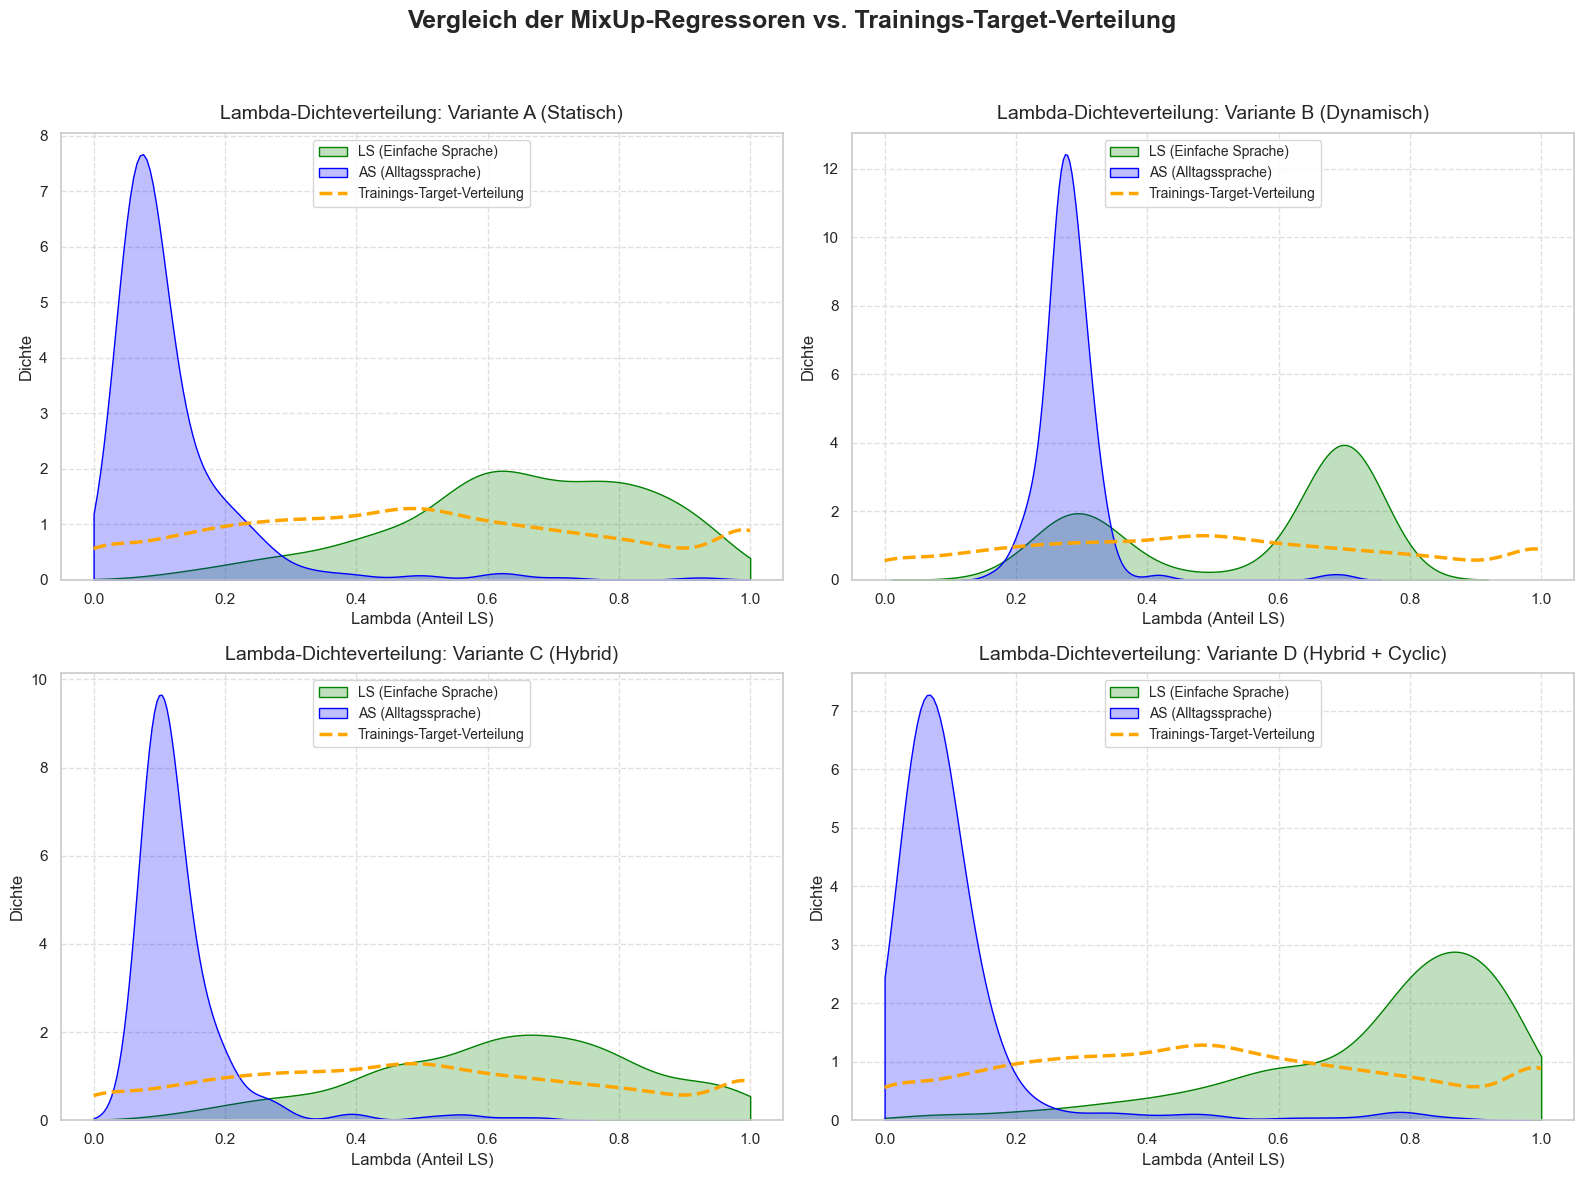

In [16]:
# 7. KDE-Plots (Dichteverteilungen) nebeneinander visualisieren
import pandas as pd
train_targets_path = "../results/train_targets_distribution.csv"
train_targets = pd.read_csv(train_targets_path)["target"]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(results.keys()):
    ls_p = results[model_name]["ls_preds"]
    as_p = results[model_name]["as_preds"]
    
    # Plot model predictions
    sns.kdeplot(ls_p, fill=True, color="green", label="LS (Einfache Sprache)", ax=axes[i], clip=(0.0, 1.0))
    sns.kdeplot(as_p, fill=True, color="blue", label="AS (Alltagssprache)", ax=axes[i], clip=(0.0, 1.0))
    
    # Overlay the training target distribution
    sns.kdeplot(train_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
    
    axes[i].set_title(f"Lambda-Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren vs. Trainings-Target-Verteilung", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_distribution_with_targets.png", dpi=300)
plt.show()
